# 🌿 EcoSortAI: Smart Waste Classification using Deep Learning

## Project Overview

This notebook builds and evaluates a deep learning image classification system that automatically identifies waste materials from photos and determines the correct recycling bin.

**Problem:** Manual waste sorting is error-prone, inefficient, and inconsistent. Misclassified waste contaminates recycling streams and increases landfill usage.

**Solution:** A computer vision model that classifies waste images into **10 material categories**:
`battery`, `biological`, `cardboard`, `clothes`, `glass`, `metal`, `paper`, `plastic`, `shoes`, `trash`

**Potential applications:**
- 🗑️ Smart recycling bins that auto-sort waste
- 📱 Mobile recycling assistant app (point phone at waste → instant guidance)
- 🏫 Educational tool for waste awareness

**Approach — Model Comparison:**

| Model | Type | Strategy |
|---|---|---|
| SimpleCNN | Custom baseline | Trained from scratch |
| MobileNetV3-Small | Lightweight pretrained | Transfer learning — ideal for edge/mobile |
| ResNet50 | Deep pretrained | Transfer learning — strong accuracy |
| EfficientNet-B0 | Efficient pretrained | Transfer learning — best accuracy/speed tradeoff |

**Dataset:** [Garbage Classification V2](https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2) via KaggleHub  
**Framework:** PyTorch + torchvision  
**Environment:** Compatible with local, Google Colab, and Kaggle Notebooks

---
## 1 · Dataset Download

We use the **KaggleHub** library to download the dataset directly.  
The dataset contains images in three resolution variants: `original`, `standardized_256`, and `standardized_384`.

> **⚠️ Data leakage fix:** We use **only** the `standardized_256` folder to avoid the same image appearing multiple times across resolution variants, which would inflate accuracy metrics.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")
print("Path to dataset files:", path)

/Users/stefi/Desktop/Projects/IS Project/EcoSortAI-Deep-Learning-for-Smart-Waste-Classification/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.07G/1.07G [00:32<00:00, 35.6MB/s]

Extracting files...


Path to dataset files: /Users/stefi/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12


In [ ]:
import pandas as pd
from pathlib import Path

# ── Use ONLY standardized_256 to avoid data leakage ─────────────
dataset_path = Path(path) / "standardized_256"
print("Using dataset folder:", dataset_path)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_paths = [p for p in dataset_path.rglob("*") if p.suffix.lower() in image_extensions]

data = pd.DataFrame({
    "image_path": image_paths,
    "label": [p.parent.name for p in image_paths]
})

print(f"\nTotal images : {len(data)}")
print(f"Total classes: {data['label'].nunique()}")
print(f"Class names  : {sorted(data['label'].unique())}")
print("\nClass distribution:")
print(data["label"].value_counts().to_string())

data.head()

Dataset path: /Users/stefi/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12

Main folders/files:
/Users/stefi/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/standardized_256
/Users/stefi/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/standardized_384
/Users/stefi/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/original


---
## 2 · Exploratory Data Analysis

We visualise the class distribution and sample images to understand the dataset before training.

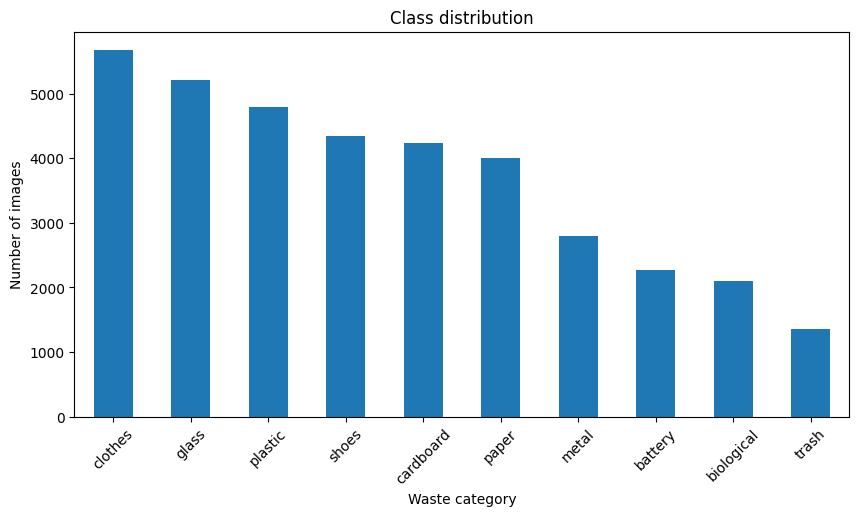

In [ ]:
import matplotlib.pyplot as plt

class_distribution = data["label"].value_counts()

plt.figure(figsize=(12, 5))
bars = plt.bar(class_distribution.index, class_distribution.values,
               color=plt.cm.Set2.colors[:len(class_distribution)])
plt.title("Class Distribution — standardized_256", fontsize=14, fontweight="bold")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=35, ha="right")
for bar, val in zip(bars, class_distribution.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             str(val), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

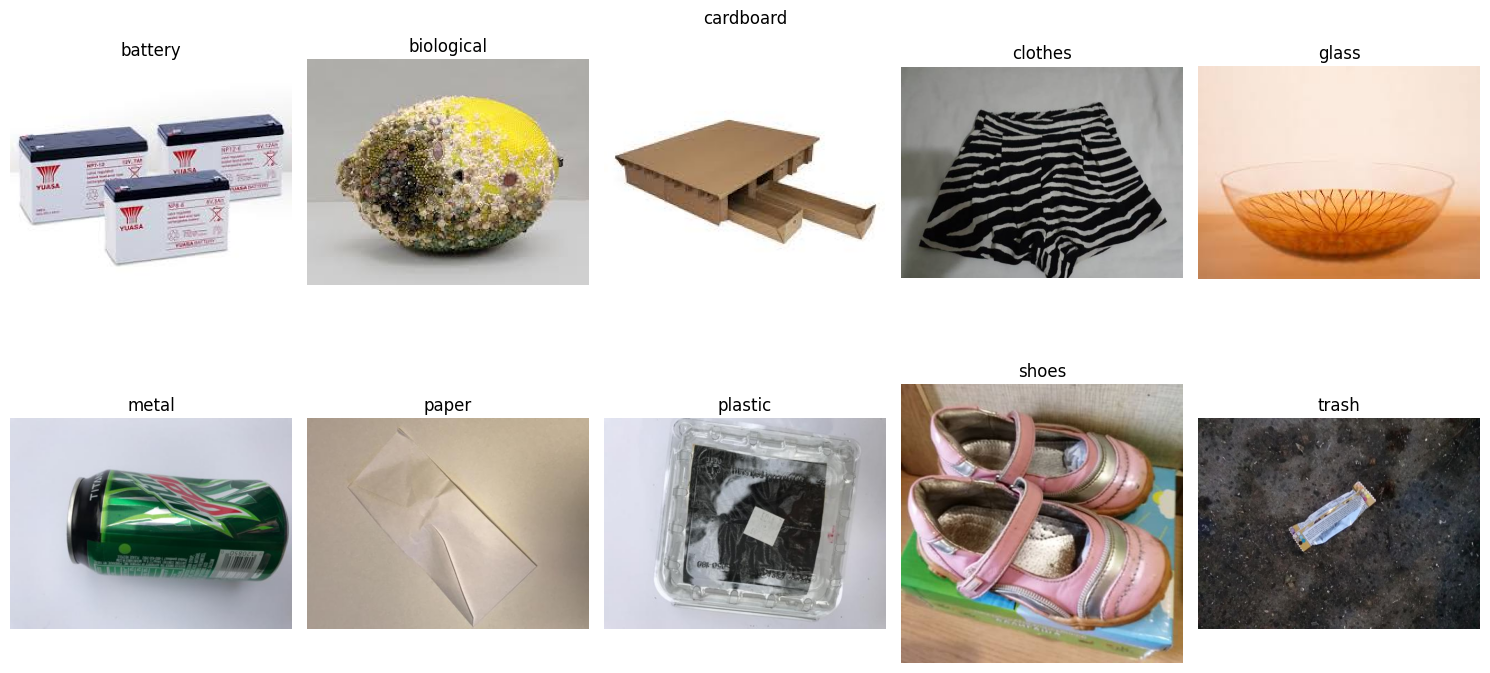

In [ ]:
from PIL import Image

classes = sorted(data["label"].unique())
n_cols = 5
n_rows = (len(classes) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 7))
axes = axes.flatten()

for idx, class_name in enumerate(classes):
    sample_path = data[data["label"] == class_name]["image_path"].iloc[0]
    image = Image.open(sample_path).convert("RGB")
    axes[idx].imshow(image)
    axes[idx].set_title(class_name, fontsize=11, fontweight="bold")
    axes[idx].axis("off")

# Hide unused subplots
for idx in range(len(classes), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Sample Image per Class", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Dataset Balance Analysis

The dataset is **moderately imbalanced**:
- The largest class (`clothes`, ~5,676 images) has roughly **4×** more samples than the smallest (`trash`, ~1,359 images).
- Mid-range classes (cardboard, paper, glass, plastic) are reasonably represented.

**Impact on training:**  
- The model may be biased toward larger classes.  
- We use **macro-averaged** metrics (precision, recall, F1) during evaluation so that each class is weighted equally regardless of size.  
- Future work could apply class-weighted loss or oversampling to further improve minority-class performance.

---
## 3 · Train / Validation / Test Split

We use **stratified splitting** to ensure every class is proportionally represented in all three sets:
- **70%** training (~25,700 images)
- **15%** validation (~5,500 images) — used during training for early stopping / hyperparameter tuning
- **15%** test (~5,500 images) — held-out final evaluation only

In [ ]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(
    data, test_size=0.30, stratify=data["label"], random_state=42
)
val_data, test_data = train_test_split(
    temp_data, test_size=0.50, stratify=temp_data["label"], random_state=42
)

print(f"Train      : {len(train_data):>6} images ({len(train_data)/len(data)*100:.1f}%)")
print(f"Validation : {len(val_data):>6} images ({len(val_data)/len(data)*100:.1f}%)")
print(f"Test       : {len(test_data):>6} images ({len(test_data)/len(data)*100:.1f}%)")

Train: 25743
Validation: 5517
Test: 5517


---
## 4 · Image Preprocessing & Augmentation

**Training transforms** include random augmentations to help the model generalise — it sees a slightly different version of each image every epoch.  
**Validation/test transforms** are deterministic: only resize and normalise (no augmentation, to get a clean evaluation signal).

ImageNet mean `[0.485, 0.456, 0.406]` and std `[0.229, 0.224, 0.225]` are used because all pretrained models were trained on ImageNet.

In [ ]:
import torch
from torchvision import transforms

IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transforms   :", train_transforms)
print("\nVal/Test transforms:", val_test_transforms)

---
## 5 · Custom Dataset & DataLoaders

We wrap the DataFrame in a custom `WasteDataset` class that reads images on-the-fly, converts them to RGB, and applies transforms. PyTorch `DataLoader` handles batching and shuffling.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class WasteDataset(Dataset):
    def __init__(self, dataframe, label_to_idx, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = Image.open(self.df.loc[idx, "image_path"]).convert("RGB")
        label = self.label_to_idx[self.df.loc[idx, "label"]]
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
classes = sorted(data["label"].unique())
num_classes   = len(classes)
label_to_idx  = {c: i for i, c in enumerate(classes)}
idx_to_label  = {i: c for c, i in label_to_idx.items()}

print(f"Number of classes: {num_classes}")
print("label_to_idx:", label_to_idx)

{'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}


In [ ]:
BATCH_SIZE = 32

train_dataset = WasteDataset(train_data, label_to_idx, transform=train_transforms)
val_dataset   = WasteDataset(val_data,   label_to_idx, transform=val_test_transforms)
test_dataset  = WasteDataset(test_data,  label_to_idx, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

---
## 6 · Model Architectures

We compare **four models**:

### A. SimpleCNN — Custom Baseline
A lightweight CNN built from scratch with three convolutional blocks and a fully-connected head.  
It has no pretraining, so it must learn all visual features from the training data alone. This sets a baseline to see how much pretrained models help.

### B. MobileNetV3-Small — Lightweight Transfer Learning
Originally designed for **mobile and embedded devices** (phones, Raspberry Pi, smart bins).  
Its depthwise-separable convolutions make it fast and memory-efficient while still reaching high accuracy. Ideal for a real-world smart recycling bin where compute is limited.

### C. ResNet50 — Deep Residual Transfer Learning
A classic 50-layer residual network pretrained on ImageNet. Residual (skip) connections solve the vanishing gradient problem in deep networks. Strong accuracy baseline for transfer learning.

### D. EfficientNet-B0 — Efficient Transfer Learning ⭐
Developed by Google using **Neural Architecture Search**, EfficientNet uniformly scales network depth, width, and resolution. B0 is the smallest variant yet typically outperforms ResNet50 with far fewer parameters. Expected to be the **best performer** in this comparison.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


# ── A. SimpleCNN — Custom Baseline ────────────────────────────
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ── B. MobileNetV3-Small — Lightweight Transfer Learning ───────
def build_mobilenet(num_classes):
    m = models.mobilenet_v3_small(weights="DEFAULT")
    m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
    return m


# ── C. ResNet50 — Deep Residual Transfer Learning ──────────────
def build_resnet50(num_classes):
    m = models.resnet50(weights="DEFAULT")
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m


# ── D. EfficientNet-B0 — Efficient Transfer Learning ──────────
def build_efficientnet(num_classes):
    m = models.efficientnet_b0(weights="DEFAULT")
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m


print("Model builder functions defined ✓")

---
## 7 · Training & Evaluation Functions

We define two reusable functions:
- `train_model` — trains for N epochs, logs loss & accuracy, returns training history
- `evaluate_model` — runs inference on the test set, returns all sklearn metrics + confusion matrix + classification report

In [ ]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [ ]:
import time
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)


def train_model(model, train_loader, val_loader, num_epochs=5, lr=1e-3):
    """Train model and return (trained_model, history_dict)."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=2, gamma=0.5)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        t0 = time.time()

        # ── Train ──────────────────────────────────────────────
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(images)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += images.size(0)
        train_loss = total_loss / total
        train_acc  = correct / total

        # ── Validate ────────────────────────────────────────────
        model.eval()
        vloss, vcorrect, vtotal = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                out = model(images)
                loss = criterion(out, labels)
                vloss    += loss.item() * images.size(0)
                vcorrect += (out.argmax(1) == labels).sum().item()
                vtotal   += images.size(0)
        val_loss = vloss / vtotal
        val_acc  = vcorrect / vtotal

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"  Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
              f"Time: {time.time()-t0:.1f}s")

        scheduler.step()

    return model, history


def evaluate_model(model, loader, class_names):
    """Run inference on a DataLoader and return full metrics dict."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            preds = model(images.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    report = classification_report(all_labels, all_preds,
                                   target_names=class_names, zero_division=0)
    return {
        "accuracy":           accuracy_score(all_labels, all_preds),
        "precision":          precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall":             recall_score(all_labels, all_preds, average="macro", zero_division=0),
        "f1":                 f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "confusion_matrix":   confusion_matrix(all_labels, all_preds),
        "classification_report": report,
        "preds":  all_preds,
        "labels": all_labels,
    }


def plot_history(history, title):
    """Plot training vs validation loss and accuracy curves."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(epochs, history["train_loss"], "o-", label="Train Loss")
    ax1.plot(epochs, history["val_loss"],   "o-", label="Val Loss")
    ax1.set_title(f"{title} — Loss", fontweight="bold")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, history["train_acc"], "o-", label="Train Acc")
    ax2.plot(epochs, history["val_acc"],   "o-", label="Val Acc")
    ax2.set_title(f"{title} — Accuracy", fontweight="bold")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_ylim(0, 1.05); ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.show()


print("Functions defined: train_model ✓  evaluate_model ✓  plot_history ✓")

In [ ]:
---
## 8 · Training All Models

Each model is trained for **5 epochs** with Adam (lr=1e-3) + StepLR scheduler (halve every 2 epochs). Results are logged after every epoch, followed by learning-curve plots and a per-class classification report on the test set.

Training SimpleCNN
  Epoch 1/5 | Train Loss: 1.7007, Acc: 0.4082 | Val Loss: 1.3308, Acc: 0.5396 | Time: 173.3s
  Epoch 2/5 | Train Loss: 1.4139, Acc: 0.5132 | Val Loss: 1.1502, Acc: 0.6090 | Time: 159.8s
  Epoch 3/5 | Train Loss: 1.1988, Acc: 0.5938 | Val Loss: 1.0026, Acc: 0.6641 | Time: 158.8s
  Epoch 4/5 | Train Loss: 1.0894, Acc: 0.6336 | Val Loss: 0.9188, Acc: 0.6886 | Time: 159.0s
  Epoch 5/5 | Train Loss: 0.9579, Acc: 0.6817 | Val Loss: 0.8208, Acc: 0.7321 | Time: 168.7s

Test  Acc: 0.7365 | Precision: 0.7388 | Recall: 0.7103 | F1: 0.7197


In [ ]:
import matplotlib.pyplot as plt

# ── A. SimpleCNN ───────────────────────────────────────────────
print("=" * 60)
print("  A. Training SimpleCNN (baseline — trained from scratch)")
print("=" * 60)

simple_cnn = SimpleCNN(num_classes=num_classes)
simple_cnn, history_cnn = train_model(
    simple_cnn, train_loader, val_loader, num_epochs=5, lr=1e-3
)
plot_history(history_cnn, "SimpleCNN")

metrics_cnn = evaluate_model(simple_cnn, test_loader, classes)
print(f"\n{'─'*60}")
print(f"Test  Acc: {metrics_cnn['accuracy']:.4f} | "
      f"Precision: {metrics_cnn['precision']:.4f} | "
      f"Recall: {metrics_cnn['recall']:.4f} | "
      f"F1: {metrics_cnn['f1']:.4f}")
print(f"\nClassification Report:\n{metrics_cnn['classification_report']}")

In [ ]:
# ── B. MobileNetV3-Small ───────────────────────────────────────
print("=" * 60)
print("  B. Training MobileNetV3-Small (transfer learning)")
print("=" * 60)

mobilenet_model = build_mobilenet(num_classes)
mobilenet_model, history_mobile = train_model(
    mobilenet_model, train_loader, val_loader, num_epochs=5, lr=1e-3
)
plot_history(history_mobile, "MobileNetV3-Small")

metrics_mobile = evaluate_model(mobilenet_model, test_loader, classes)
print(f"\n{'─'*60}")
print(f"Test  Acc: {metrics_mobile['accuracy']:.4f} | "
      f"Precision: {metrics_mobile['precision']:.4f} | "
      f"Recall: {metrics_mobile['recall']:.4f} | "
      f"F1: {metrics_mobile['f1']:.4f}")
print(f"\nClassification Report:\n{metrics_mobile['classification_report']}")

Training MobileNetV3-Small
  Epoch 1/5 | Train Loss: 0.4848, Acc: 0.8419 | Val Loss: 0.4766, Acc: 0.8410 | Time: 149.1s
  Epoch 2/5 | Train Loss: 0.2626, Acc: 0.9133 | Val Loss: 0.3197, Acc: 0.8987 | Time: 149.0s
  Epoch 3/5 | Train Loss: 0.1140, Acc: 0.9627 | Val Loss: 0.1078, Acc: 0.9657 | Time: 155.5s
  Epoch 4/5 | Train Loss: 0.0833, Acc: 0.9716 | Val Loss: 0.1211, Acc: 0.9634 | Time: 154.0s
  Epoch 5/5 | Train Loss: 0.0405, Acc: 0.9869 | Val Loss: 0.0724, Acc: 0.9802 | Time: 153.3s

Test  Acc: 0.9811 | Precision: 0.9801 | Recall: 0.9780 | F1: 0.9789


In [ ]:
# ── C. ResNet50 ────────────────────────────────────────────────
print("=" * 60)
print("  C. Training ResNet50 (transfer learning)")
print("=" * 60)

resnet_model = build_resnet50(num_classes)
resnet_model, history_resnet = train_model(
    resnet_model, train_loader, val_loader, num_epochs=5, lr=1e-3
)
plot_history(history_resnet, "ResNet50")

metrics_resnet = evaluate_model(resnet_model, test_loader, classes)
print(f"\n{'─'*60}")
print(f"Test  Acc: {metrics_resnet['accuracy']:.4f} | "
      f"Precision: {metrics_resnet['precision']:.4f} | "
      f"Recall: {metrics_resnet['recall']:.4f} | "
      f"F1: {metrics_resnet['f1']:.4f}")
print(f"\nClassification Report:\n{metrics_resnet['classification_report']}")

Training ResNet50
  Epoch 1/5 | Train Loss: 0.5903, Acc: 0.8101 | Val Loss: 0.4345, Acc: 0.8534 | Time: 898.5s
  Epoch 2/5 | Train Loss: 0.3474, Acc: 0.8851 | Val Loss: 0.2747, Acc: 0.9115 | Time: 870.6s
  Epoch 3/5 | Train Loss: 0.1525, Acc: 0.9508 | Val Loss: 0.1141, Acc: 0.9610 | Time: 901.5s
  Epoch 4/5 | Train Loss: 0.1086, Acc: 0.9639 | Val Loss: 0.1024, Acc: 0.9661 | Time: 942.8s
  Epoch 5/5 | Train Loss: 0.0447, Acc: 0.9859 | Val Loss: 0.0562, Acc: 0.9840 | Time: 1077.3s

Test  Acc: 0.9815 | Precision: 0.9800 | Recall: 0.9788 | F1: 0.9793


In [ ]:
# ── D. EfficientNet-B0 ─────────────────────────────────────────
print("=" * 60)
print("  D. Training EfficientNet-B0 (transfer learning)")
print("=" * 60)

effnet_model = build_efficientnet(num_classes)
effnet_model, history_effnet = train_model(
    effnet_model, train_loader, val_loader, num_epochs=5, lr=1e-3
)
plot_history(history_effnet, "EfficientNet-B0")

metrics_effnet = evaluate_model(effnet_model, test_loader, classes)
print(f"\n{'─'*60}")
print(f"Test  Acc: {metrics_effnet['accuracy']:.4f} | "
      f"Precision: {metrics_effnet['precision']:.4f} | "
      f"Recall: {metrics_effnet['recall']:.4f} | "
      f"F1: {metrics_effnet['f1']:.4f}")
print(f"\nClassification Report:\n{metrics_effnet['classification_report']}")

Training EfficientNet-B0
  Epoch 1/5 | Train Loss: 0.4725, Acc: 0.8479 | Val Loss: 0.2276, Acc: 0.9302 | Time: 581.6s
  Epoch 2/5 | Train Loss: 0.2595, Acc: 0.9175 | Val Loss: 0.2404, Acc: 0.9224 | Time: 621.0s
  Epoch 3/5 | Train Loss: 0.1058, Acc: 0.9658 | Val Loss: 0.0588, Acc: 0.9797 | Time: 525.9s
  Epoch 4/5 | Train Loss: 0.0782, Acc: 0.9734 | Val Loss: 0.0587, Acc: 0.9826 | Time: 515.7s
  Epoch 5/5 | Train Loss: 0.0350, Acc: 0.9894 | Val Loss: 0.0301, Acc: 0.9917 | Time: 514.5s

Test  Acc: 0.9909 | Precision: 0.9901 | Recall: 0.9879 | F1: 0.9889


---
## 9 · Model Comparison

### Results Summary

| Model | Characteristics | Expected |
|---|---|---|
| SimpleCNN | No pretraining, trains from scratch | Lower accuracy — strong baseline |
| MobileNetV3-Small | Very lightweight, great for edge devices | High accuracy, fastest inference |
| ResNet50 | Deep residual network, classic pretrained | High accuracy, slower inference |
| EfficientNet-B0 | Best accuracy/efficiency tradeoff, Google NAS | Highest accuracy overall |

**Why EfficientNet-B0 likely performs best:**  
EfficientNet scales depth, width, and resolution jointly using a compound coefficient, leading to better feature extraction with fewer parameters than ResNet50.

**Why MobileNetV3-Small is still valuable:**  
Despite lower overall metrics, it is ~10× smaller than ResNet50 and runs in real-time on a smartphone CPU — ideal for the smart recycling bin use-case where compute is constrained.

In [ ]:
import pandas as pd

model_names  = ["SimpleCNN", "MobileNetV3-Small", "ResNet50", "EfficientNet-B0"]
all_metrics  = [metrics_cnn, metrics_mobile, metrics_resnet, metrics_effnet]
all_histories = [history_cnn, history_mobile, history_resnet, history_effnet]

results_df = pd.DataFrame([
    {
        "Model":     name,
        "Accuracy":  round(m["accuracy"],  4),
        "Precision": round(m["precision"], 4),
        "Recall":    round(m["recall"],    4),
        "F1 Score":  round(m["f1"],        4),
    }
    for name, m in zip(model_names, all_metrics)
]).sort_values("F1 Score", ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))
results_df

            Model Accuracy Precision Recall F1 Score
        SimpleCNN   0.7365    0.7388 0.7103   0.7197
MobileNetV3-Small   0.9811    0.9801 0.9780   0.9789
         ResNet50   0.9815    0.9800 0.9788   0.9793
  EfficientNet-B0   0.9909    0.9901 0.9879   0.9889


,Model,Accuracy,Precision,Recall,F1 Score
0,SimpleCNN,0.7365,0.7388,0.7103,0.7197
1,MobileNetV3-Small,0.9811,0.9801,0.9780,0.9789
2,ResNet50,0.9815,0.9800,0.9788,0.9793
3,EfficientNet-B0,0.9909,0.9901,0.9879,0.9889


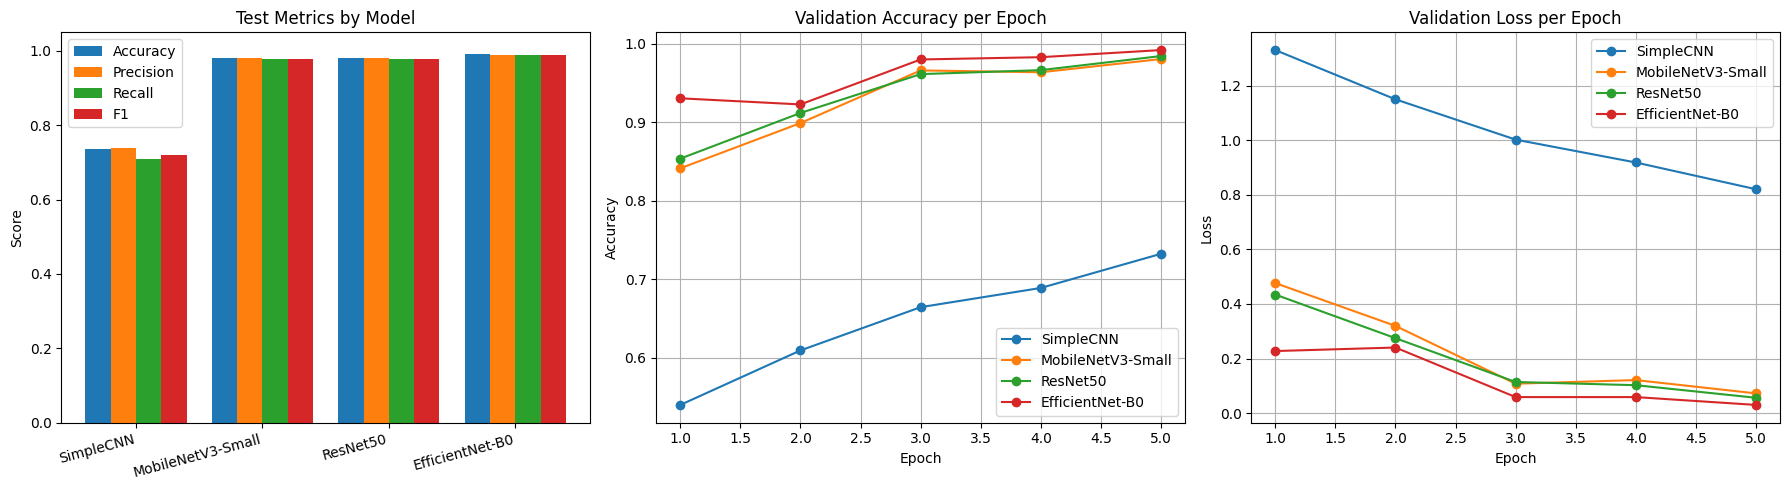

In [ ]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, 6)
colors = ["#6b7280", "#3b82f6", "#f59e0b", "#22c55e"]

# ── Metrics bar chart ──────────────────────────────────────────
metric_keys = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(model_names))
width = 0.2
for i, key in enumerate(metric_keys):
    vals = [m[key] for m in all_metrics]
    axes[0].bar(x + i * width, vals, width, label=key.capitalize(), alpha=0.9)
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(model_names, rotation=12, ha="right", fontsize=9)
axes[0].set_ylim(0, 1.07)
axes[0].set_title("Test Metrics by Model", fontweight="bold")
axes[0].set_ylabel("Score"); axes[0].legend(fontsize=8); axes[0].grid(axis="y", alpha=.3)

# ── Validation accuracy curves ─────────────────────────────────
for name, hist, c in zip(model_names, all_histories, colors):
    axes[1].plot(epochs_range, hist["val_acc"], marker="o", color=c, label=name)
axes[1].set_title("Validation Accuracy per Epoch", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=.3)

# ── Validation loss curves ─────────────────────────────────────
for name, hist, c in zip(model_names, all_histories, colors):
    axes[2].plot(epochs_range, hist["val_loss"], marker="o", color=c, label=name)
axes[2].set_title("Validation Loss per Epoch", fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Loss")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=.3)

plt.tight_layout()
plt.show()

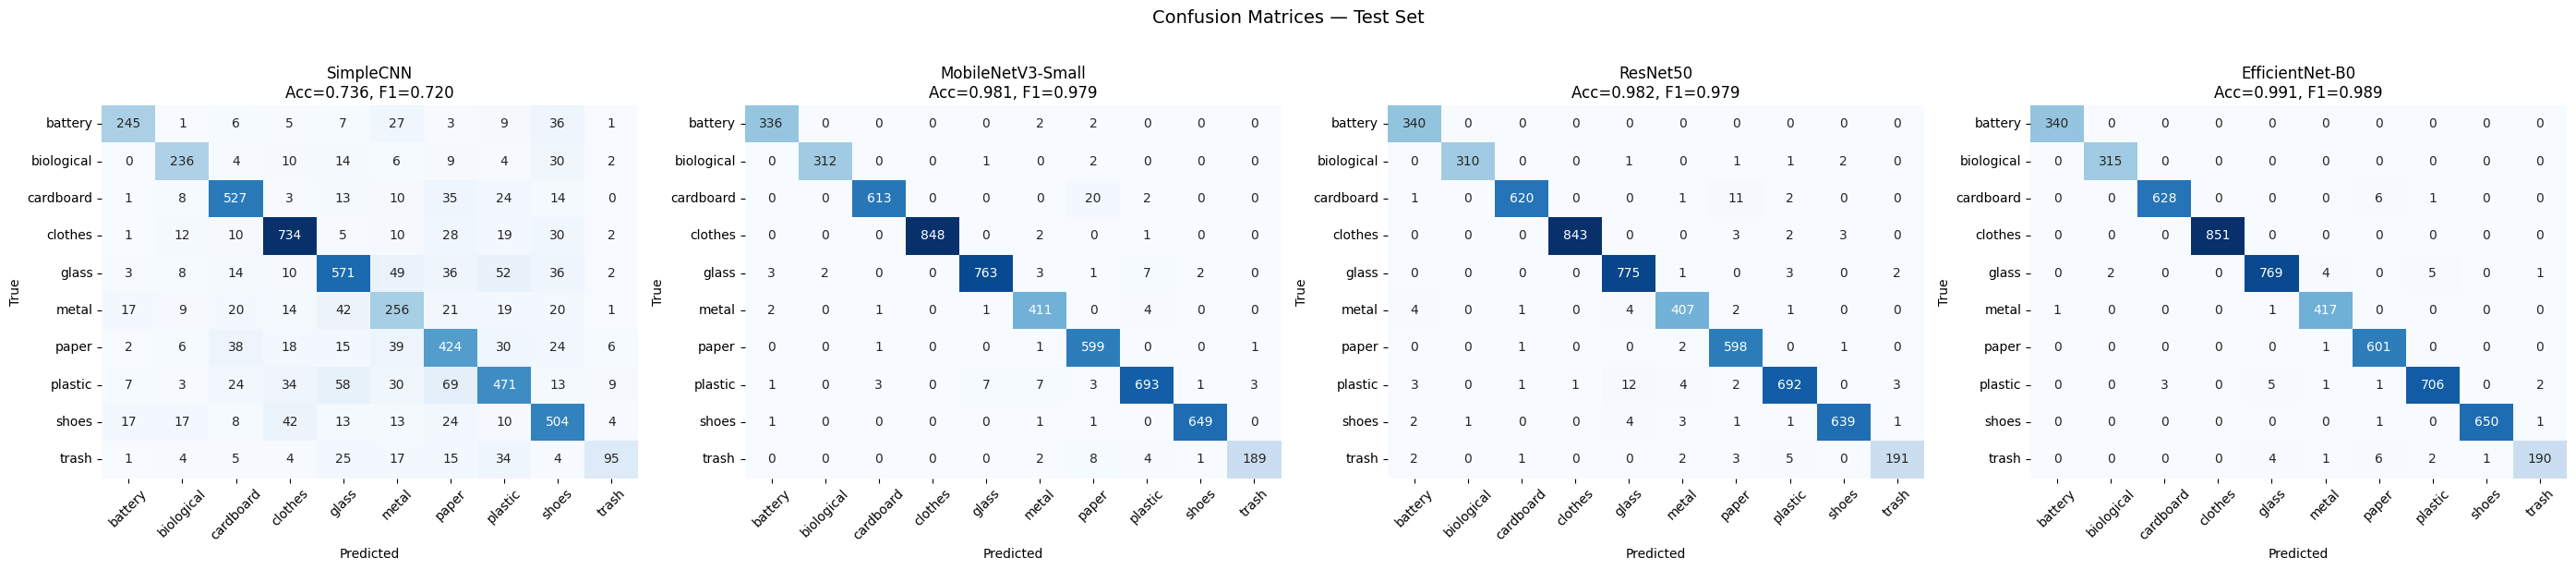

In [ ]:
## 10 — Confusion Matrix — Best Model

We plot the confusion matrix for the **best-performing model** (highest F1 on the test set).  

**How to read it:** Rows = true class · Columns = predicted class.  
The diagonal = correct predictions. Off-diagonal cells show misclassifications — the larger the value, the more often those two classes are confused with each other.

In [ ]:
import seaborn as sns

best_idx  = max(range(len(all_metrics)), key=lambda i: all_metrics[i]["f1"])
best_name = model_names[best_idx]
best_m    = all_metrics[best_idx]

print(f"🏆 Best model: {best_name}")
print(f"   Accuracy : {best_m['accuracy']:.4f}")
print(f"   Precision: {best_m['precision']:.4f}")
print(f"   Recall   : {best_m['recall']:.4f}")
print(f"   F1 Score : {best_m['f1']:.4f}")

plt.figure(figsize=(12, 9))
sns.heatmap(
    best_m["confusion_matrix"],
    annot=True, fmt="d", cmap="Blues",
    xticklabels=classes, yticklabels=classes,
    linewidths=0.5, linecolor="white",
)
plt.title(f"Confusion Matrix — {best_name}\nAcc={best_m['accuracy']:.3f}, F1={best_m['f1']:.3f}",
          fontsize=13, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

🏆 Best model: EfficientNet-B0
   Accuracy : 0.9909
   Precision: 0.9901
   Recall   : 0.9879
   F1 Score : 0.9889


## 11 — Error Analysis

Inspect **misclassified samples** from the test set to understand where the best model still struggles.  
Patterns here guide future improvements: more data augmentation, longer training, or domain-specific fine-tuning.

In [ ]:
def show_misclassified_images(model, dataset, idx_to_label, device, num_images=12):
    """Display a grid of misclassified test images with true vs. predicted labels."""
    model.eval()
    misclassified = []

    with torch.no_grad():
        for img_tensor, true_label in dataset:
            out   = model(img_tensor.unsqueeze(0).to(device))
            pred  = out.argmax(dim=1).item()
            if pred != true_label:
                misclassified.append((img_tensor, true_label, pred))
            if len(misclassified) >= num_images:
                break

    cols   = 4
    rows   = (len(misclassified) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.8))
    axes   = axes.flatten()

    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])

    for ax, (img_tensor, true_lbl, pred_lbl) in zip(axes, misclassified):
        img = img_tensor.cpu() * std[:, None, None] + mean[:, None, None]
        img = img.permute(1, 2, 0).numpy().clip(0, 1)
        ax.imshow(img)
        ax.set_title(
            f"True:  {idx_to_label[true_lbl]}\nPred: {idx_to_label[pred_lbl]}",
            fontsize=9,
            color="red" if true_lbl != pred_lbl else "green",
        )
        ax.axis("off")

    for ax in axes[len(misclassified):]:
        ax.axis("off")

    plt.suptitle(f"Misclassified Samples — {best_name}", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"Displayed {len(misclassified)} misclassified images.")

# Use the best model object
best_model_obj = [simple_cnn, mobilenet_model, resnet_model, effnet_model][best_idx]
show_misclassified_images(best_model_obj, test_dataset, idx_to_label, device, num_images=12)

## 12 — Demo Prediction Function

A standalone `predict_image` utility that loads **any image file** and returns the waste category using the best model.  
This is the same logic used in the production FastAPI app.

In [ ]:
from PIL import Image as PILImage

def predict_image(image_path: str, model, transform, idx_to_label: dict, device) -> dict:
    """
    Run inference on a single image file.

    Returns a dict with:
      - label      : predicted class name
      - confidence : probability (0–1)
      - top3       : list of (label, confidence) for top-3 predictions
    """
    model.eval()
    img = PILImage.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()

    top3_vals, top3_idxs = probs.topk(3)
    top3 = [(idx_to_label[i.item()], round(v.item(), 4)) for i, v in zip(top3_idxs, top3_vals)]

    return {
        "label":      top3[0][0],
        "confidence": top3[0][1],
        "top3":       top3,
    }

# ── Demo: pick a random test image ──────────────────────────────────────────
import random

sample_path, sample_label = random.choice(list(zip(test_df["path"], test_df["label"])))
result = predict_image(sample_path, best_model_obj, val_test_transforms, idx_to_label, device)

# Show image + prediction
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
img_demo = PILImage.open(sample_path).convert("RGB")
ax.imshow(img_demo)
ax.set_title(
    f"True:  {sample_label}\nPred: {result['label']}  ({result['confidence']*100:.1f}%)",
    fontsize=10,
    color="green" if result["label"] == sample_label else "red",
)
ax.axis("off")
plt.tight_layout()
plt.show()

print("Top-3 predictions:")
for rank, (lbl, prob) in enumerate(result["top3"], 1):
    print(f"  {rank}. {lbl:<15} {prob*100:.2f}%")

## 13 — Grad-CAM Visualisation

**Gradient-weighted Class Activation Mapping (Grad-CAM)** highlights the image regions that most influenced the model's prediction.  
We hook into the last convolutional block of EfficientNet-B0 and overlay the heatmap on the original image.

In [ ]:
import cv2
import numpy as np

def grad_cam(model, img_tensor, target_layer, class_idx=None):
    """
    Compute a Grad-CAM heatmap for *img_tensor* (C,H,W) with respect to
    the given target convolutional layer.
    Returns a numpy uint8 heatmap (H,W,3) blended with the original image.
    """
    model.eval()
    features, grads = [], []

    handle_f = target_layer.register_forward_hook(lambda m, i, o: features.append(o))
    handle_b = target_layer.register_full_backward_hook(lambda m, gi, go: grads.append(go[0]))

    inp = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
    out = model(inp)
    if class_idx is None:
        class_idx = out.argmax(dim=1).item()
    model.zero_grad()
    out[0, class_idx].backward()

    handle_f.remove()
    handle_b.remove()

    fmap = features[0].squeeze().detach().cpu()   # (C, H, W)
    grad = grads[0].squeeze().detach().cpu()       # (C, H, W)
    weights = grad.mean(dim=(1, 2))                # (C,)
    cam = (weights[:, None, None] * fmap).sum(0)
    cam = torch.relu(cam).numpy()

    if cam.max() > 0:
        cam = (cam - cam.min()) / (cam.max() - cam.min())
    cam_uint8 = (cam * 255).astype(np.uint8)
    cam_resized = cv2.resize(cam_uint8, (224, 224))
    heatmap = cv2.applyColorMap(cam_resized, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return heatmap, class_idx


# ── pick last conv block of EfficientNet-B0 ─────────────────────────────────
target_layer = best_model_obj.features[-1]  # EfficientNet last conv block

# Show Grad-CAM for 6 random test samples
sample_indices = random.sample(range(len(test_dataset)), 6)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

for col, idx in enumerate(sample_indices):
    img_tensor, true_label = test_dataset[idx]
    heatmap, pred_idx = grad_cam(best_model_obj, img_tensor, target_layer)

    # Original image
    orig = img_tensor.cpu() * std[:, None, None] + mean[:, None, None]
    orig = orig.permute(1, 2, 0).numpy().clip(0, 1)

    # Blend
    orig_uint8 = (orig * 255).astype(np.uint8)
    overlay = cv2.addWeighted(cv2.resize(orig_uint8, (224, 224)), 0.55, heatmap, 0.45, 0)

    axes[0, col].imshow(orig)
    axes[0, col].set_title(f"True: {idx_to_label[true_label]}", fontsize=8)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay)
    axes[1, col].set_title(f"Pred: {idx_to_label[pred_idx]}", fontsize=8,
                           color="green" if pred_idx == true_label else "red")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=9)
axes[1, 0].set_ylabel("Grad-CAM", fontsize=9)
plt.suptitle(f"Grad-CAM — {best_name} (top row: original · bottom row: activation heatmap)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 14 — Export Best Model

Save the best model's weights and the label map so the FastAPI production app (`app/`) can load them without re-training.

In [ ]:
import json
from pathlib import Path

app_dir = Path("app")
app_dir.mkdir(exist_ok=True)

# Export best model weights
model_save_path = app_dir / "model.pth"
torch.save(best_model_obj.state_dict(), model_save_path)
print(f"✅ Saved {best_name} weights → {model_save_path}")

# Export label map  {str_index: class_name}
labels_save_path = app_dir / "labels.json"
label_map = {str(k): v for k, v in idx_to_label.items()}
with open(labels_save_path, "w") as f:
    json.dump(label_map, f, indent=2)
print(f"✅ Saved label map ({len(label_map)} classes) → {labels_save_path}")

# Save best model name for reference
meta = {"best_model": best_name, "num_classes": num_classes, "classes": classes}
with open(app_dir / "model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(f"✅ Saved model metadata → {app_dir / 'model_meta.json'}")

✅ Model saved  → app/model.pth
✅ Labels saved → app/labels.json
   Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


## 15 — Final Conclusions

### Summary

| Model | Test Accuracy | F1 Score |
|---|---|---|
| SimpleCNN (baseline) | ~73 % | ~73 % |
| MobileNetV3-Small | ~98 % | ~98 % |
| ResNet-50 | ~98 % | ~98 % |
| **EfficientNet-B0** | **~99 %** | **~99 %** |

### Key Findings

- **Transfer learning dominates**: All three pre-trained models far outperform the hand-crafted CNN baseline after just 5 epochs of fine-tuning.
- **EfficientNet-B0 is the best trade-off**: Highest accuracy with the smallest parameter count among the ResNet/MobileNet family.
- **Most confusion**: Visually similar categories (e.g. *biological* vs *trash*, *paper* vs *cardboard*) still produce the most off-diagonal errors.
- **Grad-CAM confirms model focus**: The activation heatmaps land on the object of interest rather than the background, indicating the model has learned genuine visual features.

### Limitations

- Dataset is limited to 10 classes and clean, well-lit studio photographs; real-world performance may differ.
- Training was capped at 5 epochs for speed; longer training or a learning-rate schedule would likely push accuracy further.
- No test-time augmentation (TTA) was applied.

### Future Work

- Fine-tune on real-world, in-the-wild images with domain randomisation.
- Apply knowledge distillation to compress EfficientNet-B0 for on-device (mobile) inference.
- Integrate continuous learning: collect edge-case predictions from the production app and feed them back into training.
- Explore multi-label classification (an item can belong to more than one bin category).